In [10]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [244]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([7,3,5])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None

In [245]:
'''
def slicing_Func(Mat):
    if Mat.shape[0] == Mat.shape[1]:
        arr = []
        for i in range(Mat.shape[0]):
            index = 0
            for j in range(Mat.shape[0]):
                if i==j and index < 2:
                    if Mat[index][index] != Mat[index+1][index+1]:
                        arr.append(index)
                        index += 1
                        break
    return(arr)
'''

Cal_Gibbs = degen_Gibbs_create(Gibbs,degeneracy,False)
Cal_Gibbs

Cal_Gibbs_T = degen_Gibbs_create(Gibbs,degeneracy,True)
Cal_Gibbs_T
#print(Cal_Gibbs)

[array([[ 0.083,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.083,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.083,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.083,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.083,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.083,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.083]]),
 array([[ 0.093,  0.   ,  0.   ],
        [ 0.   ,  0.093,  0.   ],
        [ 0.   ,  0.   ,  0.093]]),
 array([[ 0.028,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.028,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.028,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.028,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.028]])]

In [246]:
#Create Qubit system with coherence
asdf = coherent_dm(2,1+0.2j)
Sys_block = asdf.full()

c = Bloch()

pointx = expect(sigmax(), asdf)
pointy = expect(sigmay(), asdf)
pointz = expect(sigmaz(), asdf)

c.add_points([pointx, pointy, pointz])
c.add_vectors([pointx, pointy, pointz])

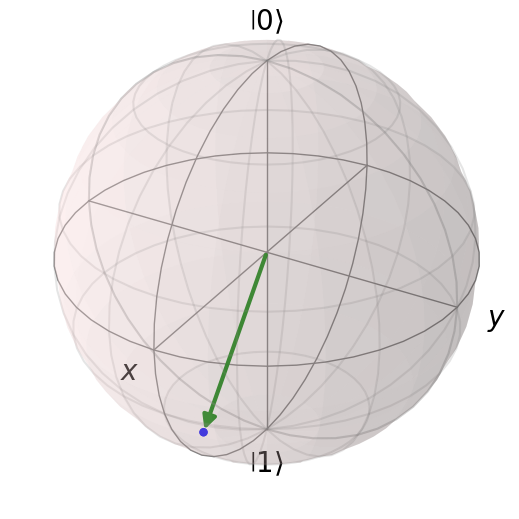

In [247]:
c.show()

In [248]:
Cal_Gibbs_T

[array([[ 0.083,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.083,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.083,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.083,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.083,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.083,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.083]]),
 array([[ 0.093,  0.   ,  0.   ],
        [ 0.   ,  0.093,  0.   ],
        [ 0.   ,  0.   ,  0.093]]),
 array([[ 0.028,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.028,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.028,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.028,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.028]])]

In [249]:
Sys_block

array([[ 0.274+0.j   ,  0.437-0.087j],
       [ 0.437+0.087j,  0.726+0.j   ]])

In [ ]:
def Unit_block_diag_compose(sys,bath,tot):
    sys_index = (sys.shape[0])
    bath_index = len(bath)

    #print("system_index",sys_index)

    index_comb = []

    for i in range(sys_index):
        for j in range(bath_index):
            comb = ((i,i),j)
            index_comb.append(comb)

    sorted_comb = sorted(index_comb, key=lambda x: x[0][0] + x[1])
    avail_values = [sorted_comb[i][0][0] + sorted_comb[i][1] for i in range(len(sorted_comb))] #possible combinations for indices corresponding energy conditions

    value_bound = (min(avail_values),max(avail_values))
    print("limited values : ", value_bound)

    #avail_values = avail_values[1:-1]
    #sorted_comb = sorted_comb[1:-1]
    print("sorted result : ",sorted_comb)
    print("avail_values : ",avail_values)

    sub_block_arr = []
    for k in range(len(sorted_comb)):
        sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
        # This condition only acts under qubit case
        #print(sys[sorted_comb[k][0][0],sorted_comb[k][0][1]])
        sub_block = (sys[sorted_comb[k][0][0],sorted_comb[k][0][1]]) * bath[sorted_comb[k][1]]
        sub_block_arr.append(sub_block)
                
    print(sub_block_arr)
    #print(len(sub_block_arr))

    arrsize = 0 
    for l in range(len(sub_block_arr)):
        arrsize += sub_block_arr[l].shape[0]

    total_block = np.zeros((arrsize,arrsize))
    
    # 기존 오류 있는 루프 구조 대신 순차적 블록 배치
    row_offset = 0
    col_offset = 0

    for sub_block in sub_block_arr:
        size = sub_block.shape[0]
        total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block
        row_offset += size
        col_offset += size


    print(total_block)
    #total_block = np.block([[block00,np.zeros((block00.shape[0],block00.shape[0]))],[np.zeros((block00.shape[0],block00.shape[0])),block11]])

    return total_block

limited values :  (0, 3)
sorted result :  [((0, 0), 0), ((0, 0), 1), ((1, 1), 0), ((0, 0), 2), ((1, 1), 1), ((1, 1), 2)]
avail_values :  [0, 1, 1, 2, 2, 3]
[array([[ 0.023+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.023+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.023+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.023+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.023+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.023+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.023+0.j]]), array([[ 0.025+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.025+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.025+0.j]]), array([[ 0.061+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.

/tmp/ipykernel_16455/1867235407.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block


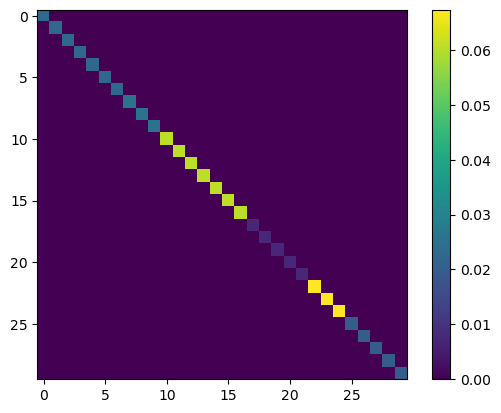

In [255]:
testbed = Unit_block_diag_compose(Sys_block,Cal_Gibbs_T,rhoRS)

plt.imshow(testbed.real)
plt.colorbar()

In [252]:
#System construction, False case
Nup_asdf_qobj = Qobj(Sys_block)
Cal_Gibbs_qobj = Qobj(Cal_Gibbs)
rhoRS_qutip = tensor(Nup_asdf_qobj, Cal_Gibbs_qobj)
rhoRS=rhoRS_qutip.full()

print(np.trace(rhoRS))

(1.000001+0j)


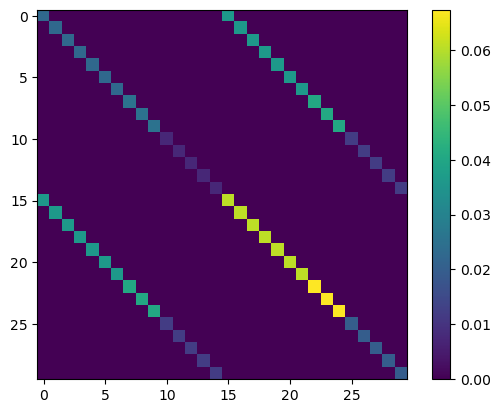

In [253]:
plt.imshow(rhoRS.real,cmap='viridis')
plt.colorbar()

#plt.savefig("/home/lie01/Works/ouput.png",format='png',bbox_inches='tight')

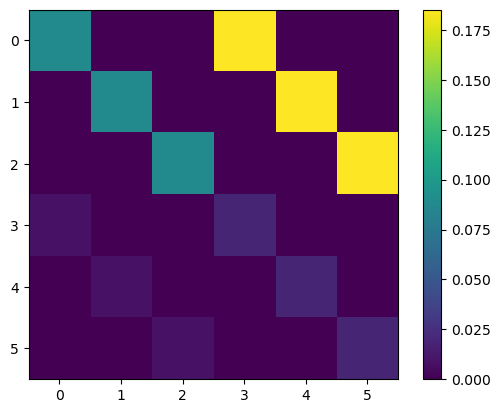

In [7]:
plt.imshow(asdfasdf,cmap='viridis')
plt.colorbar()

In [36]:
from itertools import combinations

In [40]:
arr = [0,1]
arr2 = [0,1,2]

blank = []

for i in arr:
    for j in arr2:
        comb = (i,j)
        blank.append(comb)

sorted_blank = sorted(blank, key=lambda x: x[0] + x[1])

print(sorted_blank)

[(0, 0), (0, 1), (1, 0), (0, 2), (1, 1), (1, 2)]


In [107]:
# 4개의 (2,2) 행렬 생성
A = np.array([[1, 2], 
              [3, 4]])

B = np.array([[5, 6], 
              [7, 8]])

C = np.array([[9, 10], 
              [11, 12]])

D = np.array([[13, 14], 
              [15, 16]])

# 4개의 행렬을 2x2 블록 행렬로 결합
# 결과는 4x4 행렬이 됩니다
# [[A, B],
#  [C, D]]
result = np.block([[A, B], 
                   [C, D]])

print("행렬 A:")
print(A)
print("\n행렬 B:")
print(B)
print("\n행렬 C:")
print(C)
print("\n행렬 D:")
print(D)
print("\n블록 행렬 결과:")
print(result)

print("Tuple index available :",result[3,3])

# 결과 행렬의 크기 확인
print("\n결과 행렬의 shape:", result.shape)

행렬 A:
[[1 2]
 [3 4]]

행렬 B:
[[5 6]
 [7 8]]

행렬 C:
[[ 9 10]
 [11 12]]

행렬 D:
[[13 14]
 [15 16]]

블록 행렬 결과:
[[ 1  2  5  6]
 [ 3  4  7  8]
 [ 9 10 13 14]
 [11 12 15 16]]
Tuple index available : 16

결과 행렬의 shape: (4, 4)


In [94]:
#System construction, True case
def System_block_arrange(sys,bath):
    sys_index = (sys.shape[0])
    bath_index = len(bath)

    print("system_index",sys_index)

    index_comb = []

    for i in range(sys_index):
        for j in range(bath_index):
            comb = (i,j)
            index_comb.append(comb)

    sorted_comb = sorted(index_comb, key=lambda x: x[0] + x[1])
    avail_values = [sum(sorted_comb[i]) for i in range(len(sorted_comb))]
    print("sorted result : ",sorted_comb)
    print("avail_values : ",avail_values)

    value_bound = (min(avail_values),max(avail_values))
    print("limited values : ", value_bound)

    block_arr = []
    for k in range(len(sorted_comb)):
        sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
        # This condition only acts under qubit case
        if avail_values[k] > value_bound[0] or avail_values[k] < value_bound[1]:
            for i in range(sys_index):
                for j in range(sys_index):
                    sub_block = sys[i][j] * bath[sorted_comb[k][1]]
                    
    
    print(block_arr)
    print(len(block_arr))


System_block_arrange(Sys_block,Cal_Gibbs_T)

system_index 2
sorted result :  [(0, 0), (0, 1), (1, 0), (0, 2), (1, 1), (1, 2)]
avail_values :  [0, 1, 1, 2, 2, 3]
limited values :  (0, 3)
[]
0
